# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** Lina María Castro
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

**Proyecto:** Brechas de desempeño en las pruebas Saber 11 (2020-2) entre zonas rurales y urbanas de Colombia: identificación de factores explicativos mediante aprendizaje automático

**Integrantes:** Juan Manuel Vellaizan · María Paula Orozco · Valery Nayuni Ccaulla · Nicolás Orduña

# Notebook 1 de 2: datos y análisis exploratorio
---

Este notebook reúne dos etapas del proyecto:

**Parte A. Carga, limpieza, integración y construcción de variables (secciones 1 a 14).** Se construye la **base analítica** a partir de dos fuentes oficiales:

1. **Icfes:** microdatos de Saber 11 del período 2020-2 (calendario A), con una fila por estudiante.
2. **DANE:** incidencia de pobreza multidimensional (IPM) por departamento, separada en cabeceras y zona rural.

El resultado se guarda en `data/processed/base_analitica.csv.gz`, que también usa el notebook 2 (modelos e interpretación).

**Parte B. Análisis exploratorio de la brecha rural-urbana (secciones 15 a 21).** Responde, con tablas y cinco gráficas:

1. ¿De qué tamaño es la brecha entre colegios rurales y urbanos y en qué áreas aparece?
2. ¿La ruralidad por sí sola explica la brecha, o importa más el tipo de colegio?
3. ¿En qué se diferencian los estudiantes y hogares de cada zona?
4. Si se comparan estudiantes de nivel socioeconómico similar, ¿persiste la brecha?
5. ¿Se relaciona la pobreza del territorio con el desempeño?


# Parte A. Carga, limpieza e integración de los datos

## 1. Importar librerías

In [1]:
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

### Mejorar visualización de los dataframes

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 2. Rutas del proyecto

El notebook está en la carpeta `notebooks/`, por eso las rutas empiezan con `..` (subir un nivel). Las bases originales deben estar en `data/raw/` sin modificar.

In [3]:
RUTA_RAW = os.path.join("..", "data", "raw")
RUTA_INTERIM = os.path.join("..", "data", "interim")
RUTA_PROCESSED = os.path.join("..", "data", "processed")
RUTA_TABLAS = os.path.join("..", "results", "tablas")

# Crear las carpetas de salida si todavía no existen
for ruta in [RUTA_INTERIM, RUTA_PROCESSED, RUTA_TABLAS]:
    os.makedirs(ruta, exist_ok=True)

print("Contenido de data/raw:")
for nombre in os.listdir(RUTA_RAW):
    print(" ", repr(nombre))

Contenido de data/raw:
  'anex-PMultidimensional-Departamental-2025.xlsx'
  '.gitkeep'
  'Saber_11°_2020-2_20260928.xlsx'


In [4]:
# El nombre del archivo del Icfes tiene el símbolo "°", así que se busca por su inicio y su final
archivos_saber = [a for a in os.listdir(RUTA_RAW) if a.startswith("Saber_11") and a.endswith(".xlsx")]
ARCHIVO_SABER = os.path.join(RUTA_RAW, archivos_saber[0])
ARCHIVO_DANE = os.path.join(RUTA_RAW, "anex-PMultidimensional-Departamental-2025.xlsx")

print("Icfes:", ARCHIVO_SABER)
print("DANE: ", ARCHIVO_DANE)

Icfes: ../data/raw/Saber_11°_2020-2_20260928.xlsx
DANE:  ../data/raw/anex-PMultidimensional-Departamental-2025.xlsx


## 3. Cargar la base del Icfes

El Excel del Icfes pesa 212 MB y tiene más de medio millón de filas, así que leerlo con `pd.read_excel` tarda varios minutos. Por eso:

- La **primera vez** se lee el Excel y se guarda una copia en CSV en `data/interim/`.
- Las **siguientes veces** se lee directamente el CSV, que es mucho más rápido.

Todas las columnas se cargan como texto (`dtype=str`) para no perder los ceros a la izquierda de los códigos DANE (por ejemplo, `05001` para Medellín). Las conversiones a número se hacen después, de forma explícita.

In [5]:
ARCHIVO_CSV_ICFES = os.path.join(RUTA_INTERIM, "saber11_20202.csv")

if os.path.exists(ARCHIVO_CSV_ICFES):
    print("Se encontró la copia en CSV: se carga directamente.")
    df_icfes = pd.read_csv(ARCHIVO_CSV_ICFES, dtype=str, keep_default_na=False, na_values=[""])
else:
    print("Primera ejecución: leyendo el Excel del Icfes (puede tardar varios minutos)...")
    df_icfes = pd.read_excel(ARCHIVO_SABER, dtype=str, keep_default_na=False, na_values=[""])
    df_icfes.to_csv(ARCHIVO_CSV_ICFES, index=False)
    print("Copia guardada en:", ARCHIVO_CSV_ICFES)

df_icfes.shape

Se encontró la copia en CSV: se carga directamente.


(504872, 81)

### Exploración inicial

Se define una función para no repetir el mismo bloque de exploración: muestra las dimensiones, las primeras filas y los tipos de datos.

In [6]:
def explorar_dataset(df, nombre="Dataset"):
    """
    Muestra una exploración inicial de un DataFrame.

    Parámetros:
        df (DataFrame): base de datos que se quiere explorar.
        nombre (str): nombre de la base para el encabezado.
    """
    print("=" * 80)
    print(f"EXPLORACIÓN: {nombre}")
    print("=" * 80)
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
    print("\nPrimeras 3 filas:")
    display(df.head(3))
    print("Tipos de datos (número de columnas por tipo):")
    print(df.dtypes.value_counts())

In [7]:
explorar_dataset(df_icfes, "Saber 11 2020-2 (Icfes)")

EXPLORACIÓN: Saber 11 2020-2 (Icfes)
Filas: 504,872 | Columnas: 81

Primeras 3 filas:


,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_TIENEETNIA,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,ESTU_MCPIO_RESIDE,ESTU_COD_RESIDE_MCPIO,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,FAMI_TRABAJOLABORPADRE,FAMI_TRABAJOLABORMADRE,FAMI_TIENEINTERNET,FAMI_TIENESERVICIOTV,FAMI_TIENECOMPUTADOR,FAMI_TIENELAVADORA,FAMI_TIENEHORNOMICROOGAS,FAMI_TIENEAUTOMOVIL,FAMI_TIENEMOTOCICLETA,FAMI_TIENECONSOLAVIDEOJUEGOS,FAMI_NUMLIBROS,FAMI_COMELECHEDERIVADOS,FAMI_COMECARNEPESCADOHUEVO,FAMI_COMECEREALFRUTOSLEGUMBRE,FAMI_SITUACIONECONOMICA,ESTU_DEDICACIONLECTURADIARIA,ESTU_DEDICACIONINTERNET,ESTU_HORASSEMANATRABAJA,ESTU_TIPOREMUNERACION,COLE_CODIGO_ICFES,COLE_COD_DANE_ESTABLECIMIENTO,COLE_NOMBRE_ESTABLECIMIENTO,COLE_GENERO,COLE_NATURALEZA,COLE_CALENDARIO,COLE_BILINGUE,COLE_CARACTER,COLE_COD_DANE_SEDE,COLE_NOMBRE_SEDE,COLE_SEDE_PRINCIPAL,COLE_AREA_UBICACION,COLE_JORNADA,COLE_COD_MCPIO_UBICACION,COLE_MCPIO_UBICACION,COLE_COD_DEPTO_UBICACION,COLE_DEPTO_UBICACION,ESTU_PRIVADO_LIBERTAD,ESTU_COD_MCPIO_PRESENTACION,ESTU_MCPIO_PRESENTACION,ESTU_DEPTO_PRESENTACION,ESTU_COD_DEPTO_PRESENTACION,PUNT_LECTURA_CRITICA,PERCENTIL_LECTURA_CRITICA,DESEMP_LECTURA_CRITICA,PUNT_MATEMATICAS,PERCENTIL_MATEMATICAS,DESEMP_MATEMATICAS,PUNT_C_NATURALES,PERCENTIL_C_NATURALES,DESEMP_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PERCENTIL_SOCIALES_CIUDADANAS,DESEMP_SOCIALES_CIUDADANAS,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,ESTU_ESTADOINVESTIGACION,ESTU_GENERACION-E
0,TI,SUIZA,F,2003-03-03 00:00:00,20204,SB11202040211436,ESTUDIANTE,SUIZA,No,CUNDINAMARCA,25,CAJICÁ,25126,Estrato 2,5 a 6,Dos,Técnica o tecnológica completa,Educación profesional completa,Es operario de máquinas o conduce vehículos (t...,Es operario de máquinas o conduce vehículos (t...,Si,Si,Si,Si,No,No,Si,No,26 A 100 LIBROS,3 a 5 veces por semana,1 o 2 veces por semana,3 a 5 veces por semana,Peor,30 minutos o menos,Más de 3 horas,0,No,679225,225126000431,I. E. D. RURAL ANTONIO NARIÑO,MIXTO,OFICIAL,A,N,ACADÉMICO,225126000431,I. E. D. RURAL ANTONIO NARIÑO - SEDE PRINCIPAL,S,RURAL,UNICA,25126,CAJICÁ,25,CUNDINAMARCA,N,25126,CAJICÁ,CUNDINAMARCA,25,54,57,3,65,89,3,41,29,2,33,11,1,55,81,A1,244,49,54.8823647351142,3,3,PUBLICAR,NO
1,PEP,VENEZUELA,M,2002-05-10 00:00:00,20204,SB11202040433216,ESTUDIANTE,VENEZUELA,No,CUNDINAMARCA,25,CAJICÁ,25126,Estrato 3,3 a 4,Uno,Secundaria (Bachillerato) completa,Educación profesional completa,Es vendedor o trabaja en atención al público,Es vendedor o trabaja en atención al público,Si,Si,No,No,No,No,No,No,0 A 10 LIBROS,3 a 5 veces por semana,Todos o casi todos los días,3 a 5 veces por semana,Mejor,No leo por entretenimiento,Más de 3 horas,Entre 11 y 20 horas,"Si, en efectivo",706085,225175000242,I.E. BOJACA,MIXTO,OFICIAL,A,N,ACADÉMICO,225175000242,I.E. BOJACA - SEDE PRINCIPAL,S,RURAL,NOCHE,25175,CHÍA,25,CUNDINAMARCA,N,25126,CAJICÁ,CUNDINAMARCA,25,57,67,3,43,26,2,46,45,2,49,55,2,33,6,A-,238,44,49.2523109721028,2,2,PUBLICAR,NO
2,TI,VENEZUELA,F,2003-12-14 00:00:00,20204,SB11202040244180,ESTUDIANTE,VENEZUELA,No,CUNDINAMARCA,25,CAJICÁ,25126,Estrato 1,5 a 6,Uno,Primaria incompleta,Secundaria (Bachillerato) incompleta,"Es agricultor, pesquero o jornalero","Trabaja en el hogar, no trabaja o estudia",No,Si,No,Si,Si,No,Si,No,0 A 10 LIBROS,1 o 2 veces por semana,3 a 5 veces por semana,3 a 5 veces por semana,Igual,Entre 30 y 60 minutos,30 minutos o menos,0,"Si, en efectivo",679225,225126000431,I. E. D. RURAL ANTONIO NARIÑO,MIXTO,OFICIAL,A,N,ACADÉMICO,225126000431,I. E. D. RURAL ANTONIO NARIÑO - SEDE PRINCIPAL,S,RURAL,UNICA,25126,CAJICÁ,25,CUNDINAMARCA,N,25126,CAJICÁ,CUNDINAMARCA,25,59,73,3,72,97,4,63,92,3,68,95,3,59,87,A2,325,94,40.7336723796904,1,3,PUBLICAR,GENERACION E - GRATUIDAD


Tipos de datos (número de columnas por tipo):
str    81
Name: count, dtype: int64


### Validación de la carga

Antes de limpiar, se comprueba que la base corresponde al período correcto y que el promedio del puntaje global coincide con la cifra oficial publicada por el Ministerio de Educación para 2020 (248 puntos).

In [8]:
print("Períodos en la base:")
print(df_icfes["PERIODO"].value_counts())

promedio_global = pd.to_numeric(df_icfes["PUNT_GLOBAL"]).mean()
print(f"\nPromedio del puntaje global en la base: {promedio_global:.2f} (cifra oficial MEN: 248)")

Períodos en la base:
PERIODO
20204    504872
Name: count, dtype: int64

Promedio del puntaje global en la base: 248.35 (cifra oficial MEN: 248)


## 4. Revisión de duplicados

Un estudiante no puede aparecer dos veces en el mismo período. Se revisan duplicados en toda la fila y en el identificador del estudiante (`ESTU_CONSECUTIVO`).

In [9]:
print("Filas duplicadas:", df_icfes.duplicated().sum())
print("Identificadores de estudiante duplicados:", df_icfes.duplicated(subset=["ESTU_CONSECUTIVO"]).sum())

Filas duplicadas: 0
Identificadores de estudiante duplicados: 0


## 5. Estudiantes sin cuestionario socioeconómico

Algunos estudiantes no respondieron **ninguna** pregunta del cuestionario del hogar (columnas que empiezan por `FAMI_`). Se marcan ahora, antes de seleccionar columnas, porque para esto se necesitan las 20 columnas del cuestionario.

In [10]:
columnas_fami = [c for c in df_icfes.columns if c.startswith("FAMI_")]
df_icfes["sin_cuestionario"] = df_icfes[columnas_fami].isna().all(axis=1).astype(int)

print(f"Preguntas del cuestionario del hogar: {len(columnas_fami)}")
print(f"Estudiantes sin ninguna respuesta (base completa): {df_icfes['sin_cuestionario'].sum():,}")

Preguntas del cuestionario del hogar: 20
Estudiantes sin ninguna respuesta (base completa): 11,588


## 6. Seleccionar y renombrar columnas

De las 81 columnas se conservan las que necesita el análisis y se les da un nombre más claro.

In [11]:
mapa_nombres = {
    # Identificación y control
    "ESTU_CONSECUTIVO": "id_estudiante",
    "ESTU_TIPODOCUMENTO": "tipo_documento",
    "ESTU_ESTADOINVESTIGACION": "estado_investigacion",
    "ESTU_PRIVADO_LIBERTAD": "privado_libertad",
    # Estudiante
    "ESTU_GENERO": "genero",
    "ESTU_FECHANACIMIENTO": "fecha_nacimiento",
    "ESTU_TIENEETNIA": "etnia",
    "ESTU_HORASSEMANATRABAJA": "trabajo_horas",
    "ESTU_INSE_INDIVIDUAL": "inse",
    # Hogar
    "FAMI_ESTRATOVIVIENDA": "estrato",
    "FAMI_PERSONASHOGAR": "personas_hogar",
    "FAMI_CUARTOSHOGAR": "cuartos_hogar",
    "FAMI_EDUCACIONMADRE": "educ_madre",
    "FAMI_EDUCACIONPADRE": "educ_padre",
    "FAMI_TIENEINTERNET": "internet",
    "FAMI_TIENECOMPUTADOR": "computador",
    "FAMI_NUMLIBROS": "libros",
    "FAMI_TIENESERVICIOTV": "tiene_tv",
    "FAMI_TIENELAVADORA": "tiene_lavadora",
    "FAMI_TIENEHORNOMICROOGAS": "tiene_horno",
    "FAMI_TIENEAUTOMOVIL": "tiene_automovil",
    "FAMI_TIENEMOTOCICLETA": "tiene_moto",
    "FAMI_TIENECONSOLAVIDEOJUEGOS": "tiene_consola",
    # Colegio y ubicación
    "COLE_COD_DANE_SEDE": "sede",
    "COLE_COD_DANE_ESTABLECIMIENTO": "establecimiento",
    "COLE_AREA_UBICACION": "zona",
    "COLE_NATURALEZA": "naturaleza",
    "COLE_JORNADA": "jornada",
    "COLE_CARACTER": "caracter",
    "COLE_GENERO": "genero_colegio",
    "COLE_BILINGUE": "bilingue",
    "ESTU_NSE_ESTABLECIMIENTO": "nse_colegio",
    "COLE_COD_DEPTO_UBICACION": "cod_depto",
    "COLE_COD_MCPIO_UBICACION": "cod_mcpio",
    "COLE_MCPIO_UBICACION": "municipio",
    # Puntajes
    "PUNT_GLOBAL": "punt_global",
    "PUNT_LECTURA_CRITICA": "punt_lectura_critica",
    "PUNT_MATEMATICAS": "punt_matematicas",
    "PUNT_C_NATURALES": "punt_c_naturales",
    "PUNT_SOCIALES_CIUDADANAS": "punt_sociales_ciudadanas",
    "PUNT_INGLES": "punt_ingles",
}

columnas_interes = list(mapa_nombres.keys()) + ["sin_cuestionario"]
df = df_icfes[columnas_interes].rename(columns=mapa_nombres)
del df_icfes   # liberar memoria: la base original ya no se necesita

df.shape

(504872, 42)

## 7. Tipos de datos y formato del texto

- Los puntajes y el índice socioeconómico se convierten a número.
- Los códigos DANE se dejan como texto de longitud fija (2 dígitos para departamento, 5 para municipio).
- La fecha de nacimiento se convierte a fecha.
- En los textos se quitan espacios sobrantes y en las variables del colegio se unifican las mayúsculas.

In [12]:
columnas_numericas = ["punt_global", "punt_lectura_critica", "punt_matematicas", "punt_c_naturales",
                      "punt_sociales_ciudadanas", "punt_ingles", "inse"]
for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

df["cod_depto"] = df["cod_depto"].str.strip().str.split(".").str[0].str.zfill(2)
df["cod_mcpio"] = df["cod_mcpio"].str.strip().str.split(".").str[0].str.zfill(5)
df["fecha_nacimiento"] = pd.to_datetime(df["fecha_nacimiento"].str[:10], errors="coerce", format="%Y-%m-%d")

columnas_texto = df.select_dtypes(include=["object", "string"]).columns
for columna in columnas_texto:
    df[columna] = df[columna].str.strip().str.replace(r"\s+", " ", regex=True)

columnas_colegio = ["sede", "establecimiento", "zona", "naturaleza", "jornada", "caracter",
                    "genero_colegio", "bilingue", "cod_depto", "cod_mcpio", "municipio"]
for columna in columnas_colegio:
    df[columna] = df[columna].str.upper()

df.dtypes

id_estudiante                          str
tipo_documento                         str
estado_investigacion                   str
privado_libertad                       str
genero                                 str
fecha_nacimiento            datetime64[us]
etnia                                  str
trabajo_horas                          str
inse                               float64
estrato                                str
personas_hogar                         str
cuartos_hogar                          str
educ_madre                             str
educ_padre                             str
internet                               str
computador                             str
libros                                 str
tiene_tv                               str
tiene_lavadora                         str
tiene_horno                            str
tiene_automovil                        str
tiene_moto                             str
tiene_consola                          str
sede       

## 8. Filtros de población

Cada filtro responde a un problema concreto de la base. Se define una función que aplica el filtro y **registra** cuántas filas elimina y por qué, para dejar trazabilidad de la limpieza.

| Filtro | Motivo |
|---|---|
| Resultados no publicados | Están en revisión jurídica: el puntaje no es definitivo. |
| Privados de la libertad | Sus condiciones de aplicación y escolarización no son comparables. |
| Puntaje global igual a 0 | En la escala 0-500 un cero indica ausencia o anulación, no desempeño. |
| Jornadas sabatina y nocturna | Son educación de adultos, con otra población y otro currículo. Se guardan aparte para compararlas en el análisis exploratorio. |

In [13]:
flujo_limpieza = [{"paso": "Base original Icfes 2020-2", "filas_eliminadas": 0, "filas_restantes": len(df)}]


def aplicar_filtro(df, excluir, nombre):
    """
    Elimina las filas marcadas en 'excluir' y registra el paso en flujo_limpieza.

    Parámetros:
        df (DataFrame): base antes del filtro.
        excluir (Series de booleanos): True en las filas que se eliminan.
        nombre (str): descripción del filtro.

    Retorna:
        DataFrame: base sin las filas excluidas.
    """
    n_antes = len(df)
    df = df[~excluir].copy()
    flujo_limpieza.append({"paso": nombre, "filas_eliminadas": n_antes - len(df), "filas_restantes": len(df)})
    print(f"{nombre}: se eliminan {n_antes - len(df):,} filas -> quedan {len(df):,}")
    return df

In [14]:
df = aplicar_filtro(df, df["id_estudiante"].duplicated(), "Duplicados (identificador de estudiante)")
df = aplicar_filtro(df, df["estado_investigacion"] != "PUBLICAR", "Resultados no publicados")
df = aplicar_filtro(df, df["privado_libertad"] == "S", "Privados de la libertad")
df = aplicar_filtro(df, df["punt_global"] == 0, "Puntaje global igual a cero")

# Antes de excluir la educación de adultos se guarda aparte, para compararla en el EDA
jornadas_adultos = ["SABATINA", "NOCHE"]
es_adulto = df["jornada"].isin(jornadas_adultos)
df_adultos = df[es_adulto][["punt_global", "tipo_documento", "zona", "jornada"]]
df_adultos.to_csv(os.path.join(RUTA_INTERIM, "saber11_adultos.csv"), index=False)

df = aplicar_filtro(df, es_adulto, "Jornadas sabatina y nocturna (educación de adultos)")

df_flujo = pd.DataFrame(flujo_limpieza)
df_flujo.to_csv(os.path.join(RUTA_TABLAS, "01_flujo_limpieza.csv"), index=False, encoding="utf-8-sig")
df_flujo

Duplicados (identificador de estudiante): se eliminan 0 filas -> quedan 504,872
Resultados no publicados: se eliminan 44 filas -> quedan 504,828
Privados de la libertad: se eliminan 152 filas -> quedan 504,676
Puntaje global igual a cero: se eliminan 80 filas -> quedan 504,596
Jornadas sabatina y nocturna (educación de adultos): se eliminan 45,689 filas -> quedan 458,907


,paso,filas_eliminadas,filas_restantes
0,Base original Icfes 2020-2,0,504872
1,Duplicados (identificador de estudiante),0,504872
2,Resultados no publicados,44,504828
3,Privados de la libertad,152,504676
4,Puntaje global igual a cero,80,504596
5,Jornadas sabatina y nocturna (educación de adu...,45689,458907


## 9. Valores atípicos y verificación del puntaje global

**Edad.** Se calcula a la fecha de inicio de la aplicación (7 de noviembre de 2020). Una edad fuera del rango de 12 a 60 años indica una fecha mal digitada, así que se convierte en faltante.

**Puntaje global.** Se cuentan los atípicos con la regla del rango intercuartílico (IQR), pero **no se eliminan**: la escala está acotada entre 0 y 500 y los valores extremos son desempeños reales, no errores.

In [15]:
fecha_examen = pd.Timestamp("2020-11-07")
edad = (fecha_examen - df["fecha_nacimiento"]).dt.days / 365.25
edad_invalida = ~edad.between(12, 60)
df["edad"] = edad.where(~edad_invalida)
print(f"Edades imposibles convertidas en faltante: {edad_invalida.sum():,}")

q1 = df["punt_global"].quantile(0.25)
q3 = df["punt_global"].quantile(0.75)
iqr = q3 - q1
limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
es_atipico = (df["punt_global"] < limite_inferior) | (df["punt_global"] > limite_superior)
print(f"Límites IQR: {limite_inferior:.1f} a {limite_superior:.1f}")
print(f"Puntajes globales atípicos (se conservan): {es_atipico.sum():,}")
pd.DataFrame({"atipicos": es_atipico.groupby(df["zona"]).sum(),
              "porcentaje": es_atipico.groupby(df["zona"]).mean() * 100})

Edades imposibles convertidas en faltante: 233
Límites IQR: 110.0 a 390.0
Puntajes globales atípicos (se conservan): 1,703


,atipicos,porcentaje
zona,,
RURAL,116,0.15
URBANO,1587,0.42


**¿Por qué no usar los puntajes por área como predictores?** El Icfes calcula el puntaje global con los cinco puntajes por área:

$$\text{Global} = \frac{3\,(LC + MAT + CN + SOC) + ING}{13} \times 5$$

Se comprueba en los datos. Si la fórmula se cumple, usar las áreas para predecir el global sería una **fuga de información**: el modelo tendría un ajuste perfecto, pero no diría nada sobre la brecha.

In [16]:
global_calculado = (3 * (df["punt_lectura_critica"] + df["punt_matematicas"] + df["punt_c_naturales"]
                         + df["punt_sociales_ciudadanas"]) + df["punt_ingles"]) / 13 * 5
diferencia = (global_calculado - df["punt_global"]).abs()
print(f"La fórmula reproduce el puntaje global (diferencia <= 1 punto) en el {(diferencia <= 1).mean() * 100:.2f} % de los casos")
print(f"Diferencia máxima: {diferencia.max():.2f} puntos (solo redondeo)")

La fórmula reproduce el puntaje global (diferencia <= 1 punto) en el 99.93 % de los casos
Diferencia máxima: 0.46 puntos (solo redondeo)


## 10. Valores faltantes

Se revisa el porcentaje de faltantes por zona. Si la no respuesta fuera mucho mayor en la zona rural, eliminar esas filas sesgaría la comparación.

In [17]:
columnas_revisar = ["estrato", "educ_madre", "educ_padre", "internet", "computador", "libros",
                    "personas_hogar", "cuartos_hogar", "trabajo_horas", "etnia", "inse", "caracter",
                    "bilingue", "edad"]
df_faltantes = df.groupby("zona")[columnas_revisar].apply(lambda x: x.isna().mean() * 100).T
df_faltantes["total"] = df[columnas_revisar].isna().mean() * 100
df_faltantes = df_faltantes.sort_values("total", ascending=False)
df_faltantes.to_csv(os.path.join(RUTA_TABLAS, "01_faltantes_por_zona.csv"), encoding="utf-8-sig")
df_faltantes

zona,RURAL,URBANO,total
bilingue,29.42,13.36,16.09
computador,3.60,3.60,3.60
estrato,3.40,2.94,3.02
trabajo_horas,2.73,3.07,3.01
cuartos_hogar,2.57,2.85,2.80
personas_hogar,2.43,2.72,2.67
inse,2.11,2.52,2.45
libros,2.25,2.45,2.41
internet,2.20,2.38,2.35
educ_madre,2.16,2.38,2.35


En las variables del hogar y del estudiante la no respuesta es baja (alrededor del 3 %) y **similar entre zonas**. Por eso no se eliminan filas ni se imputa con la moda: en las variables categóricas la no respuesta queda como una categoría propia, «No reporta» (sección 11).

La excepción es la variable del colegio «bilingüe», que falta en el 16 % de los casos (29 % en lo rural). Como es un dato del colegio y no del hogar, también queda como «No reporta»; así el modelo puede estimar si los colegios sin este dato son distintos.

## 11. Recodificación de variables categóricas

Igual que en el taller de limpieza, se usan **diccionarios** con `.map()` para traducir las respuestas a categorías más claras. Tres criterios guían la recodificación:

- **«No reporta».** Los vacíos, «No sabe» y «No aplica» se agrupan en esta categoría.
- **«Sin estrato».** Se mantiene como categoría propia: no es un dato faltante, sino la situación real de muchos hogares rurales.
- **Categorías pequeñas.** Se agrupan (educación de los padres en 7 niveles, estratos 5 y 6 juntos) para que no queden categorías con muy pocos casos.

In [18]:
NR = "No reporta"

dic_naturaleza = {"OFICIAL": "Oficial", "NO OFICIAL": "No oficial"}
dic_jornada = {"MAÑANA": "Mañana", "TARDE": "Tarde", "UNICA": "Única", "COMPLETA": "Completa"}
dic_caracter = {"ACADÉMICO": "Académico", "TÉCNICO": "Técnico", "TÉCNICO/ACADÉMICO": "Técnico/Académico",
                "NO APLICA": "No aplica"}
dic_genero_colegio = {"MIXTO": "Mixto", "FEMENINO": "Femenino", "MASCULINO": "Masculino"}
dic_si_no = {"Si": "Sí", "No": "No", "S": "Sí", "N": "No"}
dic_estrato = {"Estrato 1": "Estrato 1", "Estrato 2": "Estrato 2", "Estrato 3": "Estrato 3",
               "Estrato 4": "Estrato 4", "Estrato 5": "Estrato 5-6", "Estrato 6": "Estrato 5-6",
               "Sin Estrato": "Sin estrato"}
dic_educacion = {
    "Ninguno": "Primaria o menos", "Primaria incompleta": "Primaria o menos",
    "Primaria completa": "Primaria o menos",
    "Secundaria (Bachillerato) incompleta": "Secundaria incompleta",
    "Secundaria (Bachillerato) completa": "Secundaria completa",
    "Técnica o tecnológica incompleta": "Superior incompleta",
    "Educación profesional incompleta": "Superior incompleta",
    "Técnica o tecnológica completa": "Técnica/tecnológica completa",
    "Educación profesional completa": "Profesional completa",
    "Postgrado": "Posgrado",
}
dic_libros = {"0 A 10 LIBROS": "0-10", "11 A 25 LIBROS": "11-25", "26 A 100 LIBROS": "26-100",
              "MÁS DE 100 LIBROS": "Más de 100"}
dic_trabajo = {"0": "No trabaja", "Menos de 10 horas": "Menos de 10 h", "Entre 11 y 20 horas": "11-20 h",
               "Entre 21 y 30 horas": "21-30 h", "Más de 30 horas": "Más de 30 h"}

df["naturaleza"] = df["naturaleza"].map(dic_naturaleza)
df["jornada"] = df["jornada"].map(dic_jornada)
df["caracter"] = df["caracter"].map(dic_caracter).fillna(NR)
df["genero_colegio"] = df["genero_colegio"].map(dic_genero_colegio)
df["bilingue"] = df["bilingue"].map(dic_si_no).fillna(NR)
df["estrato"] = df["estrato"].map(dic_estrato).fillna(NR)
df["educ_madre"] = df["educ_madre"].map(dic_educacion).fillna(NR)
df["educ_padre"] = df["educ_padre"].map(dic_educacion).fillna(NR)
df["internet"] = df["internet"].map(dic_si_no).fillna(NR)
df["computador"] = df["computador"].map(dic_si_no).fillna(NR)
df["libros"] = df["libros"].map(dic_libros).fillna(NR)
df["etnia"] = df["etnia"].map(dic_si_no).fillna(NR)
df["trabajo_horas"] = df["trabajo_horas"].map(dic_trabajo).fillna(NR)

# NSE del colegio (1 a 4): solo faltan 49 casos, se completan con la moda
df["nse_colegio"] = "NSE " + df["nse_colegio"].fillna(df["nse_colegio"].mode()[0])
# Género del estudiante: solo faltan 8 casos, se completan con la moda
df["genero"] = df["genero"].fillna(df["genero"].mode()[0])

for columna in ["naturaleza", "jornada", "estrato", "educ_madre", "internet", "libros"]:
    print(df[columna].value_counts(), "\n")

naturaleza
Oficial       360675
No oficial     98232
Name: count, dtype: int64 

jornada
Mañana      200451
Única       132145
Completa     77493
Tarde        48818
Name: count, dtype: int64 

estrato
Estrato 2      165812
Estrato 1      137318
Estrato 3       96448
Estrato 4       22218
Sin estrato     13936
No reporta      13860
Estrato 5-6      9315
Name: count, dtype: int64 

educ_madre
Secundaria completa             127789
Primaria o menos                110347
Secundaria incompleta            61436
Profesional completa             54269
Técnica/tecnológica completa     48060
Superior incompleta              26223
No reporta                       19797
Posgrado                         10986
Name: count, dtype: int64 

internet
Sí            317399
No            130725
No reporta     10783
Name: count, dtype: int64 

libros
0-10          182413
11-25         140327
26-100         95240
Más de 100     29849
No reporta     11078
Name: count, dtype: int64 



## 12. Ingeniería de variables

Se crean variables con sentido económico para el problema:

| Variable | Cómo se construye | Por qué es relevante |
|---|---|---|
| `rural` | 1 si el colegio es rural | Variable de interés del proyecto |
| `extraedad` | 1 si tiene 19 años o más | Indicador de repitencia o ingreso tardío (rezago escolar) |
| `personas_hogar` | Punto medio del rango reportado | Tamaño del hogar |
| `hacinamiento` | Personas / cuartos | Privación de vivienda del IPM; espacio para estudiar en casa durante las clases remotas |
| `indice_bienes` | Suma de 6 bienes durables (0-6) | Riqueza del hogar, distinta de internet y computador |
| `conectividad_completa` | Internet **y** computador | Condición mínima para estudiar a distancia en 2020 |
| `educ_max_padres` | Máximo nivel entre madre y padre (1-7) | Capital humano del hogar |
| `trabaja` | 1 si trabaja alguna hora | Costo de oportunidad del tiempo de estudio |

In [19]:
df["rural"] = (df["zona"] == "RURAL").astype(int)
df["extraedad"] = (df["edad"] >= 19).astype(float).where(df["edad"].notna())

dic_personas = {"1 a 2": 1.5, "3 a 4": 3.5, "5 a 6": 5.5, "7 a 8": 7.5, "9 o más": 9.5}
dic_cuartos = {"Uno": 1, "Dos": 2, "Tres": 3, "Cuatro": 4, "Cinco": 5, "Seis o mas": 6}
df["personas_hogar"] = df["personas_hogar"].map(dic_personas)
df["hacinamiento"] = df["personas_hogar"] / df["cuartos_hogar"].map(dic_cuartos)

bienes = ["tiene_tv", "tiene_lavadora", "tiene_horno", "tiene_automovil", "tiene_moto", "tiene_consola"]
for bien in bienes:
    df[bien] = df[bien].map({"Si": 1, "No": 0})
df["indice_bienes"] = df[bienes].sum(axis=1, min_count=1)   # queda vacío si no respondió ningún bien

df["conectividad_completa"] = ((df["internet"] == "Sí") & (df["computador"] == "Sí")).astype(int)

dic_nivel_educativo = {"Primaria o menos": 1, "Secundaria incompleta": 2, "Secundaria completa": 3,
                       "Superior incompleta": 4, "Técnica/tecnológica completa": 5,
                       "Profesional completa": 6, "Posgrado": 7}
df["educ_max_padres"] = pd.concat([df["educ_madre"].map(dic_nivel_educativo),
                                   df["educ_padre"].map(dic_nivel_educativo)], axis=1).max(axis=1)

df["trabaja"] = df["trabajo_horas"].isin(["Menos de 10 h", "11-20 h", "21-30 h", "Más de 30 h"]).astype(int)
df["municipio"] = df["municipio"].str.title()

df[["rural", "extraedad", "hacinamiento", "indice_bienes", "conectividad_completa",
    "educ_max_padres", "trabaja"]].describe()

,rural,extraedad,hacinamiento,indice_bienes,conectividad_completa,educ_max_padres,trabaja
count,"458,907.00","458,674.00","445,391.00","448,979.00","458,907.00","444,130.00","458,907.00"
mean,0.17,0.08,1.71,2.93,0.54,3.45,0.37
std,0.38,0.28,0.84,1.47,0.50,1.81,0.48
min,0.00,0.00,0.25,0.00,0.00,1.00,0.00
25%,0.00,0.00,1.17,2.00,0.00,2.00,0.00
50%,0.00,0.00,1.75,3.00,1.00,3.00,0.00
75%,0.00,0.00,1.83,4.00,1.00,5.00,1.00
max,1.00,1.00,9.50,6.00,1.00,7.00,1.00


## 13. Integración con el DANE: pobreza multidimensional 2020

El anexo del DANE tiene el IPM de cada departamento para 2018-2025, con tres columnas por año: total, cabeceras y centros poblados y rural disperso. Como el encabezado ocupa dos filas, se lee sin encabezado (`header=None`) y se ubican las columnas de 2020.

In [20]:
df_dane_crudo = pd.read_excel(ARCHIVO_DANE, sheet_name="IPM_Departamentos", header=None)
df_dane_crudo.iloc[10:16, :10]

,0,1,2,3,4,5,6,7,8,9
10,Cifras en porcentaje,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,Departamento,2018,NaN,NaN,2019,NaN,NaN,2020**,NaN,NaN
12,NaN,Total,Cabeceras,Centros poblados \ny rural disperso,Total,Cabeceras,Centros poblados \ny rural disperso,Total,Cabeceras,Centros poblados \ny rural disperso
13,Antioquia,15.30,9.60,35.40,15.70,10.20,35.90,14.90,10.20,32.70
14,Atlántico,21.10,20,39.50,14.90,13.70,38,14.10,13.10,33.90
15,Bogotá D.C.,4.10,4.10,19.20,7.10,7.10,16.50,7.50,7.50,15.40


In [21]:
# Fila donde empieza el encabezado (dice "Departamento") y columna donde aparece el año 2020
fila_encabezado = df_dane_crudo.index[df_dane_crudo[0] == "Departamento"][0]
columna_2020 = None
for j in range(df_dane_crudo.shape[1]):
    if str(df_dane_crudo.iloc[fila_encabezado, j]).startswith("2020"):
        columna_2020 = j
print("Fila del encabezado:", fila_encabezado, "| Columna del año 2020:", columna_2020)

# Las 33 filas de departamentos empiezan dos filas debajo del encabezado
df_ipm = df_dane_crudo.iloc[fila_encabezado + 2: fila_encabezado + 2 + 33,
                            [0, columna_2020, columna_2020 + 1, columna_2020 + 2]]
df_ipm.columns = ["departamento", "ipm_total", "ipm_cabecera", "ipm_rural"]
for columna in ["ipm_total", "ipm_cabecera", "ipm_rural"]:
    df_ipm[columna] = pd.to_numeric(df_ipm[columna], errors="coerce")
df_ipm["departamento"] = df_ipm["departamento"].str.strip()
print("Departamentos leídos:", len(df_ipm))
df_ipm.head()

Fila del encabezado: 11 | Columna del año 2020: 7
Departamentos leídos: 33


,departamento,ipm_total,ipm_cabecera,ipm_rural
13,Antioquia,14.90,10.20,32.70
14,Atlántico,14.10,13.10,33.90
15,Bogotá D.C.,7.50,7.50,15.40
16,Bolívar,28.10,21.50,47.10
17,Boyacá,11.70,4.30,22.40


El Icfes identifica el departamento con el **código DIVIPOLA** y el DANE con el **nombre**, que además se escribe distinto (por ejemplo, «NORTE SANTANDER» y «Norte de Santander»). Para no depender de coincidencias de texto se usa un diccionario de correspondencia explícito, igual que en el taller de combinación de datos con la DIVIPOLA.

In [22]:
divipola_a_dane = {
    "05": "Antioquia", "08": "Atlántico", "11": "Bogotá D.C.", "13": "Bolívar", "15": "Boyacá",
    "17": "Caldas", "18": "Caquetá", "19": "Cauca", "20": "Cesar", "23": "Córdoba",
    "25": "Cundinamarca", "27": "Chocó", "41": "Huila", "44": "La Guajira", "47": "Magdalena",
    "50": "Meta", "52": "Nariño", "54": "Norte de Santander", "63": "Quindío", "66": "Risaralda",
    "68": "Santander", "70": "Sucre", "73": "Tolima", "76": "Valle del Cauca", "81": "Arauca",
    "85": "Casanare", "86": "Putumayo", "88": "San Andrés", "91": "Amazonas", "94": "Guainía",
    "95": "Guaviare", "97": "Vaupés", "99": "Vichada",
}

# Verificar que todos los nombres del diccionario existen en el anexo del DANE
faltan = set(divipola_a_dane.values()) - set(df_ipm["departamento"])
print("Departamentos sin correspondencia:", faltan if faltan else "ninguno")

df["departamento"] = df["cod_depto"].map(divipola_a_dane)

n_antes = len(df)
df = df.merge(df_ipm, on="departamento", how="left", validate="m:1")
print(f"Filas antes: {n_antes:,} | después: {len(df):,} (la unión no debe duplicar filas)")

Departamentos sin correspondencia: ninguno
Filas antes: 458,907 | después: 458,907 (la unión no debe duplicar filas)


Cada estudiante recibe el IPM de **su departamento en su zona**: el de las cabeceras si el colegio es urbano y el de la zona rural si es rural. Así se tienen 66 contextos (33 departamentos × 2 zonas).

San Andrés no tiene IPM rural publicado para 2020, así que se usa su valor total y se marca con la variable `ipm_imputado`.

In [23]:
df["ipm_imputado"] = ((df["zona"] == "RURAL") & df["ipm_rural"].isna()).astype(int)
df["ipm_rural"] = df["ipm_rural"].fillna(df["ipm_total"])
df["ipm_zona"] = np.where(df["zona"] == "RURAL", df["ipm_rural"], df["ipm_cabecera"])
df = df.rename(columns={"ipm_total": "ipm_depto_total"})

print("Estudiantes sin IPM asignado:", df["ipm_zona"].isna().sum())
print("Estudiantes con IPM rural imputado (San Andrés):", df["ipm_imputado"].sum())
print("Contextos departamento x zona:", df.groupby(["departamento", "zona"]).ngroups)

tabla_ipm = df.groupby(["departamento", "zona"])["ipm_zona"].first().unstack()
tabla_ipm.to_csv(os.path.join(RUTA_TABLAS, "01_ipm_2020_por_departamento_y_zona.csv"), encoding="utf-8-sig")
tabla_ipm.head()

Estudiantes sin IPM asignado: 0
Estudiantes con IPM rural imputado (San Andrés): 225
Contextos departamento x zona: 66


zona,RURAL,URBANO
departamento,,
Amazonas,53.50,24.30
Antioquia,32.70,10.20
Arauca,31.10,23.40
Atlántico,33.90,13.10
Bogotá D.C.,15.40,7.50


## 14. Base analítica final

Se ordenan las columnas, se revisa el resultado y se guarda la base en `data/processed/`.

In [24]:
columnas_finales = [
    "id_estudiante", "sede", "establecimiento", "cod_depto", "departamento", "cod_mcpio", "municipio",
    "punt_global", "punt_lectura_critica", "punt_matematicas", "punt_c_naturales",
    "punt_sociales_ciudadanas", "punt_ingles",
    "zona", "rural", "naturaleza", "jornada", "caracter", "genero_colegio", "bilingue", "nse_colegio",
    "estrato", "educ_madre", "educ_padre", "educ_max_padres", "internet", "computador",
    "conectividad_completa", "libros", "personas_hogar", "hacinamiento", "indice_bienes",
    "genero", "etnia", "edad", "extraedad", "trabajo_horas", "trabaja",
    "ipm_zona", "ipm_depto_total", "ipm_imputado", "inse", "sin_cuestionario",
]
df_final = df[columnas_finales]

ARCHIVO_BASE = os.path.join(RUTA_PROCESSED, "base_analitica.csv.gz")
df_final.to_csv(ARCHIVO_BASE, index=False, compression="gzip")

print(f"Base analítica guardada: {df_final.shape[0]:,} estudiantes x {df_final.shape[1]} variables")
print(f"Rurales: {df_final['rural'].sum():,} | Urbanos: {(1 - df_final['rural']).sum():,}")
print(f"Con cuestionario socioeconómico (muestra de modelamiento): {(df_final['sin_cuestionario'] == 0).sum():,}")
df_final.head()

Base analítica guardada: 458,907 estudiantes x 43 variables
Rurales: 78,186 | Urbanos: 380,721
Con cuestionario socioeconómico (muestra de modelamiento): 449,695


,id_estudiante,sede,establecimiento,cod_depto,departamento,cod_mcpio,municipio,punt_global,punt_lectura_critica,punt_matematicas,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles,zona,rural,naturaleza,jornada,caracter,genero_colegio,bilingue,nse_colegio,estrato,educ_madre,educ_padre,educ_max_padres,internet,computador,conectividad_completa,libros,personas_hogar,hacinamiento,indice_bienes,genero,etnia,edad,extraedad,trabajo_horas,trabaja,ipm_zona,ipm_depto_total,ipm_imputado,inse,sin_cuestionario
0,SB11202040211436,225126000431,225126000431,25,Cundinamarca,25126,Cajicá,244,54,65,41,33,55.00,RURAL,1,Oficial,Única,Académico,Mixto,No,NSE 3,Estrato 2,Profesional completa,Técnica/tecnológica completa,6.00,Sí,Sí,1,26-100,5.50,2.75,3.00,F,No,17.68,0.00,No trabaja,0,17.10,11.40,0,54.88,0
1,SB11202040244180,225126000431,225126000431,25,Cundinamarca,25126,Cajicá,325,59,72,63,68,59.00,RURAL,1,Oficial,Única,Académico,Mixto,No,NSE 3,Estrato 1,Secundaria incompleta,Primaria o menos,2.00,No,No,0,0-10,5.50,5.50,4.00,F,No,16.90,0.00,No trabaja,0,17.10,11.40,0,40.73,0
2,SB11202040210971,225126000431,225126000431,25,Cundinamarca,25126,Cajicá,238,47,55,46,43,47.00,RURAL,1,Oficial,Única,Académico,Mixto,No,NSE 3,Sin estrato,Profesional completa,Secundaria incompleta,6.00,Sí,No,0,11-25,5.50,2.75,3.00,M,No,17.57,0.00,No trabaja,0,17.10,11.40,0,48.22,0
3,SB11202040235382,225126000288,225126000288,25,Cundinamarca,25126,Cajicá,202,37,48,44,32,43.00,URBANO,0,Oficial,Única,Técnico/Académico,Mixto,No,NSE 3,Estrato 5-6,Profesional completa,Secundaria completa,6.00,Sí,Sí,1,0-10,5.50,1.83,4.00,F,No,16.68,0.00,Menos de 10 h,1,9.40,11.40,0,60.91,0
4,SB11202040237578,225126000288,225126000288,25,Cundinamarca,25126,Cajicá,222,58,45,38,40,35.00,URBANO,0,Oficial,Única,Técnico/Académico,Mixto,No,NSE 3,Sin estrato,Primaria o menos,Superior incompleta,4.00,Sí,No,0,0-10,1.50,0.50,3.00,M,No,17.90,0.00,Menos de 10 h,1,9.40,11.40,0,43.24,0


**Resumen de la parte A.**

- **Carga y validación.** La base del Icfes tiene 504.872 estudiantes y su promedio coincide con la cifra oficial (248).
- **Limpieza.** Después de los filtros quedan 458.907 estudiantes de jornadas regulares.
- **Integración.** El 100 % de los estudiantes quedó emparejado con el IPM de su departamento y zona.
- **Siguiente paso.** La base resultante alimenta el análisis exploratorio (parte B) y los modelos (notebook 2).

# Parte B. Análisis exploratorio de la brecha rural-urbana

## 15. Preparar el análisis

Se importa `matplotlib` para las gráficas y se vuelve a leer la base analítica que se acaba de guardar, para trabajar exactamente con la versión final del archivo (con los mismos tipos de datos que usará el notebook 2).

In [25]:
import matplotlib.pyplot as plt

RUTA_FIGURAS = os.path.join("..", "results", "figuras")
os.makedirs(RUTA_FIGURAS, exist_ok=True)

df = pd.read_csv(ARCHIVO_BASE,
                 dtype={"sede": str, "cod_depto": str, "cod_mcpio": str, "id_estudiante": str})
urbano = df[df["zona"] == "URBANO"]
rural = df[df["zona"] == "RURAL"]
print(f"Estudiantes: {len(df):,} | urbanos: {len(urbano):,} | rurales: {len(rural):,}")

Estudiantes: 458,907 | urbanos: 380,721 | rurales: 78,186


### Estilo de las gráficas

Se definen una sola vez los colores de cada zona (azul urbano, naranja rural) y un estilo limpio, para que todas las gráficas se lean igual.

In [26]:
COLOR = {"URBANO": "#2a78d6", "RURAL": "#eb6834"}
GRIS = "#8a8984"

plt.rcParams.update({
    "figure.dpi": 100, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "axes.axisbelow": True,
})


def guardar_figura(nombre):
    """Guarda la figura actual en results/figuras con buena resolución y la muestra."""
    plt.savefig(os.path.join(RUTA_FIGURAS, nombre), dpi=200, bbox_inches="tight")
    plt.show()

## 16. Tamaño de la brecha

Para cada prueba se calculan:

- **Promedios por zona y brecha** (urbano − rural).
- **Intervalo de confianza del 95 %** de la brecha: brecha ± 1,96 × error estándar.
- **d de Cohen**: la brecha dividida por la desviación estándar combinada. Permite comparar áreas con escalas distintas; en ciencias sociales un d cercano a 0,5 se considera un efecto moderado.

In [27]:
def comparar_zonas(columna):
    """
    Calcula la brecha urbano - rural de una variable numérica.

    Parámetros:
        columna (str): nombre de la variable (por ejemplo, 'punt_global').

    Retorna:
        dict: medias, brecha, intervalo de confianza del 95 % y d de Cohen.
    """
    a = urbano[columna].dropna()
    b = rural[columna].dropna()
    brecha = a.mean() - b.mean()
    error_estandar = np.sqrt(a.var() / len(a) + b.var() / len(b))
    desv_combinada = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return {"media_urbano": a.mean(), "media_rural": b.mean(), "brecha": brecha,
            "ic95_inf": brecha - 1.96 * error_estandar, "ic95_sup": brecha + 1.96 * error_estandar,
            "d_cohen": brecha / desv_combinada}


pruebas = {"punt_global": "Puntaje global (0-500)", "punt_lectura_critica": "Lectura crítica",
           "punt_matematicas": "Matemáticas", "punt_c_naturales": "Ciencias naturales",
           "punt_sociales_ciudadanas": "Sociales y ciudadanas", "punt_ingles": "Inglés"}

filas = []
for columna, nombre in pruebas.items():
    resultado = comparar_zonas(columna)
    resultado["prueba"] = nombre
    filas.append(resultado)

df_brechas = pd.DataFrame(filas).set_index("prueba")
df_brechas.to_csv(os.path.join(RUTA_TABLAS, "02_brechas_por_area.csv"), encoding="utf-8-sig")
df_brechas

,media_urbano,media_rural,brecha,ic95_inf,ic95_sup,d_cohen
prueba,,,,,,
Puntaje global (0-500),256.85,228.56,28.29,27.95,28.63,0.60
Lectura crítica,53.78,48.13,5.65,5.57,5.72,0.58
Matemáticas,52.87,46.89,5.98,5.90,6.06,0.53
Ciencias naturales,49.77,44.91,4.86,4.79,4.94,0.47
Sociales y ciudadanas,50.01,43.85,6.16,6.07,6.24,0.53
Inglés,48.51,42.93,5.58,5.51,5.66,0.50


**Gráfica 1. Distribución del puntaje global por zona.** Compara la distribución completa y no solo los promedios, para ver si toda la curva rural está desplazada o si la diferencia la explican unos pocos casos extremos.

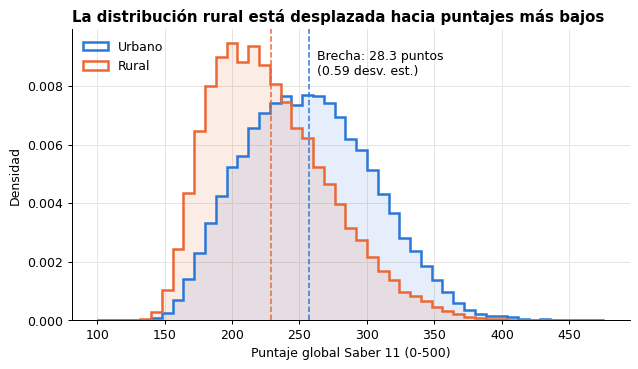

In [28]:
brecha_global = df_brechas.loc["Puntaje global (0-500)", "brecha"]
bins = np.arange(100, 480, 8)

plt.figure(figsize=(8, 4.2))
for zona, datos in [("URBANO", urbano), ("RURAL", rural)]:
    plt.hist(datos["punt_global"], bins=bins, density=True, histtype="step", linewidth=2,
             color=COLOR[zona], label=zona.title())
    plt.hist(datos["punt_global"], bins=bins, density=True, alpha=0.12, color=COLOR[zona])
    plt.axvline(datos["punt_global"].mean(), color=COLOR[zona], linestyle="--", linewidth=1.2)
plt.text(urbano["punt_global"].mean() + 6, plt.ylim()[1] * 0.93,
         f"Brecha: {brecha_global:.1f} puntos\n({brecha_global / df['punt_global'].std():.2f} desv. est.)", va="top")
plt.title("La distribución rural está desplazada hacia puntajes más bajos")
plt.xlabel("Puntaje global Saber 11 (0-500)")
plt.ylabel("Densidad")
plt.legend(loc="upper left", frameon=False)
guardar_figura("G1_distribucion_puntaje_por_zona.png")

**Lectura.** Toda la distribución rural está corrida hacia la izquierda: la brecha es de **28,3 puntos** (0,6 desviaciones estándar) y no se debe a unos pocos casos extremos. En la tabla se ve que la brecha aparece en las cinco áreas (entre 4,9 y 6,2 puntos sobre 100), así que es un rezago general y no de una sola asignatura.

## 17. ¿Basta la ruralidad para explicar la brecha?

Si la desventaja fuera de «ser rural», los estudiantes rurales deberían tener puntajes más bajos en cualquier tipo de colegio. Se compara por naturaleza del colegio (oficial y no oficial).

In [29]:
df_naturaleza = df.groupby(["naturaleza", "zona"])["punt_global"].agg(["mean", "count"]).reset_index()
df_naturaleza.to_csv(os.path.join(RUTA_TABLAS, "02_puntaje_naturaleza_x_zona.csv"), index=False, encoding="utf-8-sig")
df_naturaleza

,naturaleza,zona,mean,count
0,No oficial,RURAL,291.53,4584
1,No oficial,URBANO,278.31,93648
2,Oficial,RURAL,224.64,73602
3,Oficial,URBANO,249.85,287073


**Gráfica 2. Puntaje global por naturaleza del colegio y zona.** Pone a prueba la idea de que la ruralidad, por sí sola, explica la brecha.

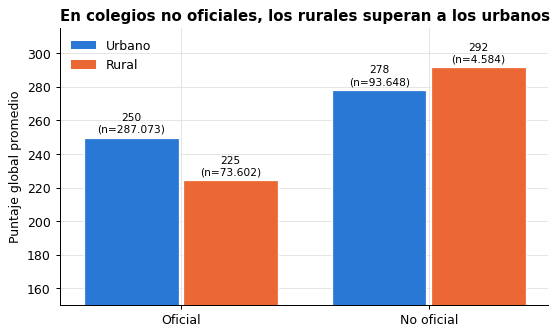

In [30]:
plt.figure(figsize=(7, 4))
posiciones = {"Oficial": 0, "No oficial": 1}
for _, fila in df_naturaleza.iterrows():
    x = posiciones[fila["naturaleza"]] + (-0.2 if fila["zona"] == "URBANO" else 0.2)
    plt.bar(x, fila["mean"], width=0.38, color=COLOR[fila["zona"]], edgecolor="white")
    plt.text(x, fila["mean"] + 3, f"{fila['mean']:.0f}\n(n={fila['count']:,})".replace(",", "."),
             ha="center", fontsize=8.5)
plt.xticks([0, 1], ["Oficial", "No oficial"])
plt.ylim(150, 315)
plt.bar(0, 0, color=COLOR["URBANO"], label="Urbano")
plt.bar(0, 0, color=COLOR["RURAL"], label="Rural")
plt.legend(loc="upper left", frameon=False)
plt.title("En colegios no oficiales, los rurales superan a los urbanos")
plt.ylabel("Puntaje global promedio")
guardar_figura("G2_puntaje_naturaleza_x_zona.png")

**Lectura.** En los colegios **no oficiales** los estudiantes rurales (291,5) superan a los urbanos (278,3). La brecha está en el **sector oficial**: 249,9 en lo urbano frente a 224,6 en lo rural, y el 94 % de los estudiantes rurales está en colegios oficiales. Pesa más qué colegios y qué población hay en cada zona que la ubicación en sí; esto justifica buscar los factores que hay detrás de la brecha.

## 18. ¿En qué se diferencian los estudiantes de cada zona?

Se calcula, para cada zona, el porcentaje de estudiantes con características asociadas al desempeño. Se usa un diccionario en el que cada llave es el nombre del indicador y cada valor es una condición (una Serie de verdadero/falso).

In [31]:
indicadores = {
    "Colegio oficial": df["naturaleza"] == "Oficial",
    "Internet en el hogar": df["internet"] == "Sí",
    "Computador en el hogar": df["computador"] == "Sí",
    "Internet y computador": df["conectividad_completa"] == 1,
    "Estrato 1 o sin estrato": df["estrato"].isin(["Estrato 1", "Sin estrato"]),
    "Madre con primaria o menos": df["educ_madre"] == "Primaria o menos",
    "Más de 25 libros en casa": df["libros"].isin(["26-100", "Más de 100"]),
    "Estudiante trabaja": df["trabaja"] == 1,
    "Extraedad (19+ años)": df["extraedad"] == 1,
    "Pertenece a grupo étnico": df["etnia"] == "Sí",
    "Jornada única o completa": df["jornada"].isin(["Única", "Completa"]),
}

filas = []
for nombre, condicion in indicadores.items():
    porcentajes = condicion.groupby(df["zona"]).mean() * 100
    filas.append({"indicador": nombre, "urbano": porcentajes["URBANO"], "rural": porcentajes["RURAL"]})

df_composicion = pd.DataFrame(filas)
df_composicion["diferencia_pp"] = df_composicion["urbano"] - df_composicion["rural"]
df_composicion = df_composicion.sort_values("diferencia_pp")
df_composicion.to_csv(os.path.join(RUTA_TABLAS, "02_composicion_por_zona.csv"), index=False, encoding="utf-8-sig")
df_composicion

,indicador,urbano,rural,diferencia_pp
5,Madre con primaria o menos,19.76,44.91,-25.15
4,Estrato 1 o sin estrato,28.95,52.47,-23.52
7,Estudiante trabaja,33.31,52.60,-19.29
0,Colegio oficial,75.40,94.14,-18.73
9,Pertenece a grupo étnico,4.44,17.38,-12.94
8,Extraedad (19+ años),7.55,12.76,-5.21
10,Jornada única o completa,45.42,46.95,-1.52
6,Más de 25 libros en casa,28.86,19.46,9.40
2,Computador en el hogar,65.15,34.16,30.99
3,Internet y computador,60.14,24.25,35.89


**Gráfica 3. Características de estudiantes y hogares por zona.** Cada línea une el porcentaje urbano (azul) con el rural (naranja). Cuanto más larga la línea, mayor la diferencia entre zonas.

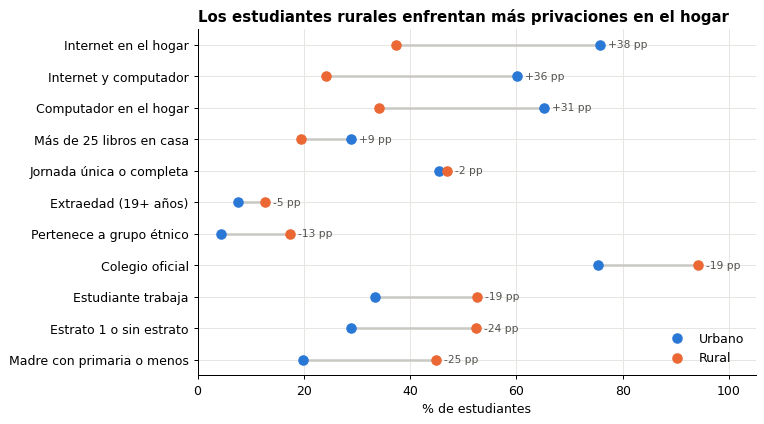

In [32]:
plt.figure(figsize=(8, 5))
y = np.arange(len(df_composicion))
plt.hlines(y, df_composicion["rural"], df_composicion["urbano"], color="#c9c8c3", linewidth=2)
plt.scatter(df_composicion["urbano"], y, color=COLOR["URBANO"], s=55, zorder=3, label="Urbano")
plt.scatter(df_composicion["rural"], y, color=COLOR["RURAL"], s=55, zorder=3, label="Rural")
for i, (_, fila) in enumerate(df_composicion.iterrows()):
    plt.text(max(fila["urbano"], fila["rural"]) + 1.5, i, f"{fila['diferencia_pp']:+.0f} pp",
             va="center", fontsize=8.5, color="#52514e")
plt.yticks(y, df_composicion["indicador"])
plt.xlim(0, 105)
plt.xlabel("% de estudiantes")
plt.title("Los estudiantes rurales enfrentan más privaciones en el hogar")
plt.legend(loc="lower right", frameon=False)
guardar_figura("G3_composicion_por_zona.png")

**Lectura.** Las mayores diferencias están en **conectividad**: 37 % de los estudiantes rurales tiene internet en casa, frente al 76 % de los urbanos, y solo el 24 % tiene internet y computador. También hay diferencias grandes en **educación de la madre** (45 % con primaria o menos, frente a 20 %), en **estrato** y en **trabajo** del estudiante (53 % frente a 33 %). Como la prueba se presentó en noviembre de 2020, después de meses de clases remotas, la falta de conectividad es un canal especialmente relevante en este período.

## 19. A igual nivel socioeconómico, ¿persiste la brecha?

Se divide a los estudiantes en diez grupos (deciles) según el índice socioeconómico individual del Icfes (INSE) y se compara el puntaje de cada zona **dentro** de cada decil. Si la brecha fuera solo socioeconómica, dentro de cada decil debería desaparecer.

In [33]:
df_inse = df.dropna(subset=["inse"]).copy()
df_inse["decil_inse"] = pd.qcut(df_inse["inse"], 10, labels=False) + 1

df_gradiente = df_inse.groupby(["decil_inse", "zona"])["punt_global"].mean().unstack()
df_gradiente["brecha"] = df_gradiente["URBANO"] - df_gradiente["RURAL"]
df_gradiente.to_csv(os.path.join(RUTA_TABLAS, "02_gradiente_inse_por_zona.csv"), encoding="utf-8-sig")
print(f"Brecha promedio dentro de los deciles: {df_gradiente['brecha'].mean():.1f} puntos")
df_gradiente

Brecha promedio dentro de los deciles: 13.2 puntos


zona,RURAL,URBANO,brecha
decil_inse,,,
1,216.76,229.62,12.86
2,220.60,233.75,13.15
3,223.72,238.42,14.70
4,228.02,243.53,15.51
5,230.17,248.96,18.80
6,235.26,253.21,17.95
7,241.53,258.93,17.39
8,250.59,265.46,14.87
9,265.77,275.23,9.47


**Gráfica 4. Puntaje global por decil del índice socioeconómico y zona.** Compara estudiantes de nivel socioeconómico similar.

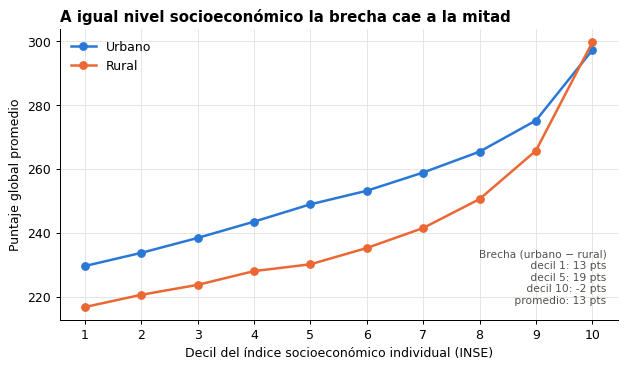

In [34]:
plt.figure(figsize=(8, 4.2))
for zona in ["URBANO", "RURAL"]:
    plt.plot(df_gradiente.index, df_gradiente[zona], color=COLOR[zona], linewidth=2, marker="o",
             label=zona.title())
plt.text(0.98, 0.05,
         f"Brecha (urbano − rural)\n decil 1: {df_gradiente['brecha'].iloc[0]:.0f} pts\n"
         f" decil 5: {df_gradiente['brecha'].iloc[4]:.0f} pts\n decil 10: {df_gradiente['brecha'].iloc[-1]:.0f} pts\n"
         f" promedio: {df_gradiente['brecha'].mean():.0f} pts",
         transform=plt.gca().transAxes, ha="right", va="bottom", fontsize=8.5, color="#52514e")
plt.xticks(range(1, 11))
plt.xlabel("Decil del índice socioeconómico individual (INSE)")
plt.ylabel("Puntaje global promedio")
plt.title("A igual nivel socioeconómico la brecha cae a la mitad")
plt.legend(loc="upper left", frameon=False)
guardar_figura("G4_gradiente_inse_por_zona.png")

**Lectura.** En ambas zonas el puntaje sube con el nivel socioeconómico, y la línea rural siempre está por debajo, salvo en el decil más alto. Dentro de un mismo decil la brecha promedio es de **13,2 puntos**, menos de la mitad de la brecha total (28,3). Buena parte de la brecha es socioeconómica, pero no toda: hay factores del colegio y del territorio que el INSE no captura.

Lo mismo se ve con el nivel socioeconómico **del colegio** (NSE, de 1 a 4), que resume la composición de los compañeros: en los colegios de NSE 3 y 4 la brecha prácticamente desaparece.

In [35]:
df_nse = df.groupby(["nse_colegio", "zona"])["punt_global"].agg(["mean", "count"]).unstack()
df_nse["brecha"] = df_nse[("mean", "URBANO")] - df_nse[("mean", "RURAL")]
df_nse.to_csv(os.path.join(RUTA_TABLAS, "02_brecha_dentro_nse_colegio.csv"), encoding="utf-8-sig")
df_nse

mean         count         brecha
zona         RURAL URBANO  RURAL  URBANO       
nse_colegio                                    
NSE 1       216.16 231.79  20752    3075  15.64
NSE 2       225.77 239.32  50115  176962  13.55
NSE 3       268.56 267.79   5127  179489  -0.77
NSE 4       316.24 314.26   2192   21195  -1.97

## 20. Pobreza del territorio y desempeño

Se agrupa a los estudiantes en los 66 contextos de departamento y zona y se compara el IPM de cada contexto (DANE) con su puntaje promedio.

In [36]:
df_contextos = df.groupby(["departamento", "zona"]).agg(ipm=("ipm_zona", "first"),
                                                         puntaje=("punt_global", "mean"),
                                                         estudiantes=("punt_global", "size")).reset_index()
correlacion = df_contextos["ipm"].corr(df_contextos["puntaje"])
pendiente, intercepto = np.polyfit(df_contextos["ipm"], df_contextos["puntaje"], 1,
                                   w=np.sqrt(df_contextos["estudiantes"]))
print(f"Correlación IPM - puntaje (66 contextos): {correlacion:.2f}")
print(f"Pendiente: {pendiente:.2f} puntos por cada punto porcentual de IPM")
df_contextos.to_csv(os.path.join(RUTA_TABLAS, "02_ipm_vs_puntaje_contextos.csv"), index=False, encoding="utf-8-sig")

Correlación IPM - puntaje (66 contextos): -0.85
Pendiente: -1.22 puntos por cada punto porcentual de IPM


**Gráfica 5. Pobreza multidimensional del territorio y puntaje promedio.** Cada punto es un departamento en una zona, y su tamaño depende del número de estudiantes. La línea es una recta ajustada que pondera más los contextos con más estudiantes.

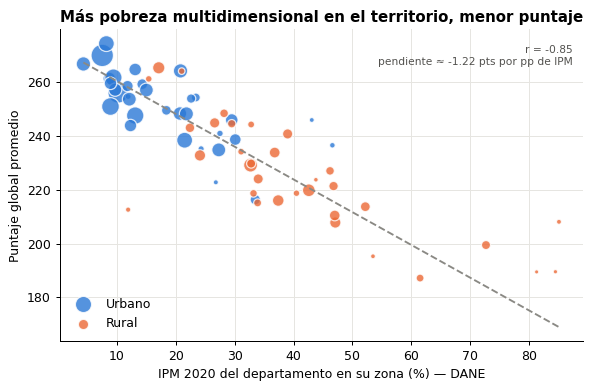

In [37]:
plt.figure(figsize=(7.5, 4.5))
for zona in ["URBANO", "RURAL"]:
    datos = df_contextos[df_contextos["zona"] == zona]
    plt.scatter(datos["ipm"], datos["puntaje"], s=np.sqrt(datos["estudiantes"]) * 1.2,
                color=COLOR[zona], alpha=0.8, edgecolor="white", label=zona.title())
x = np.linspace(df_contextos["ipm"].min(), df_contextos["ipm"].max(), 50)
plt.plot(x, pendiente * x + intercepto, color=GRIS, linestyle="--")
plt.text(0.98, 0.95, f"r = {correlacion:.2f}\npendiente ≈ {pendiente:.2f} pts por pp de IPM",
         transform=plt.gca().transAxes, ha="right", va="top", fontsize=8.5, color="#52514e")
plt.xlabel("IPM 2020 del departamento en su zona (%) — DANE")
plt.ylabel("Puntaje global promedio")
plt.title("Más pobreza multidimensional en el territorio, menor puntaje")
plt.legend(loc="lower left", frameon=False)
guardar_figura("G5_ipm_vs_puntaje.png")

**Lectura.** La relación es fuerte y negativa (r = −0,85): los contextos más pobres, casi siempre rurales, tienen puntajes más bajos. Cada punto porcentual adicional de IPM se asocia con cerca de 1,2 puntos menos. Por eso el IPM territorial se incluye como variable en los modelos.

## 21. Tablas complementarias

Estas tablas no llevan gráfica, pero sustentan el análisis y se usan en el documento.

In [38]:
# Brecha por departamento
df_departamentos = df.groupby(["departamento", "zona"])["punt_global"].agg(["mean", "count"]).unstack()
df_departamentos.columns = ["media_rural", "media_urbano", "n_rural", "n_urbano"]
df_departamentos["brecha"] = df_departamentos["media_urbano"] - df_departamentos["media_rural"]
df_departamentos = df_departamentos.sort_values("brecha", ascending=False)
df_departamentos.to_csv(os.path.join(RUTA_TABLAS, "02_brecha_por_departamento.csv"), encoding="utf-8-sig")
print("Departamentos con mayor y menor brecha (urbano - rural):")
pd.concat([df_departamentos.head(5), df_departamentos.tail(5)])

Departamentos con mayor y menor brecha (urbano - rural):


,media_rural,media_urbano,n_rural,n_urbano,brecha
departamento,,,,,
Guainía,189.53,245.89,101,169,56.36
San Andrés,212.58,254.61,225,339,42.03
Amazonas,195.27,235.19,154,416,39.91
La Guajira,199.43,238.63,1900,5329,39.19
Norte de Santander,227.00,264.13,1583,11888,37.13
Casanare,244.23,259.20,651,3824,14.97
Meta,248.37,257.15,1603,8736,8.78
Bogotá D.C.,261.16,269.87,549,71224,8.71
Cundinamarca,265.28,261.67,6460,24869,-3.61


In [39]:
# Conectividad del hogar y puntaje, por zona
df_con = df[df["internet"] != "No reporta"].copy()
df_con["conectividad"] = np.where(df_con["conectividad_completa"] == 1, "Internet y computador",
                                  np.where((df_con["internet"] == "Sí") | (df_con["computador"] == "Sí"),
                                           "Solo uno de los dos", "Ninguno"))
tabla_conectividad = df_con.groupby(["conectividad", "zona"])["punt_global"].mean().unstack()
tabla_conectividad.to_csv(os.path.join(RUTA_TABLAS, "02_conectividad_x_zona.csv"), encoding="utf-8-sig")
tabla_conectividad

zona,RURAL,URBANO
conectividad,,
Internet y computador,252.13,267.96
Ninguno,218.50,232.16
Solo uno de los dos,226.81,245.31


In [40]:
# Jornada, estrato y educación de la madre
for variable in ["jornada", "estrato", "educ_madre"]:
    tabla = df.groupby([variable, "zona"])["punt_global"].mean().unstack()
    tabla.to_csv(os.path.join(RUTA_TABLAS, f"02_puntaje_{variable}_x_zona.csv"), encoding="utf-8-sig")
    display(tabla)

zona,RURAL,URBANO
jornada,,
Completa,241.46,283.48
Mañana,222.77,252.28
Tarde,219.33,245.85
Única,231.71,252.76


zona,RURAL,URBANO
estrato,,
Estrato 1,227.62,244.43
Estrato 2,233.82,256.75
Estrato 3,238.42,268.00
Estrato 4,241.33,281.57
Estrato 5-6,231.27,279.16
No reporta,218.54,250.22
Sin estrato,203.46,219.93


zona,RURAL,URBANO
educ_madre,,
No reporta,220.60,254.04
Posgrado,294.74,305.87
Primaria o menos,219.48,238.19
Profesional completa,261.43,279.04
Secundaria completa,231.44,253.44
Secundaria incompleta,225.59,245.12
Superior incompleta,245.76,267.45
Técnica/tecnológica completa,250.60,269.48


In [41]:
# No respuesta por zona (% de 'No reporta') y estudiantes sin cuestionario
variables_nr = ["estrato", "internet", "computador", "educ_madre", "libros"]
tabla_nr = pd.DataFrame({v: (df[v] == "No reporta").groupby(df["zona"]).mean() * 100 for v in variables_nr})
tabla_nr["sin_cuestionario"] = df.groupby("zona")["sin_cuestionario"].mean() * 100
tabla_nr.T

zona,RURAL,URBANO
estrato,3.40,2.94
internet,2.20,2.38
computador,3.60,3.60
educ_madre,3.65,4.45
libros,2.25,2.45
sin_cuestionario,1.75,2.06


In [42]:
# Educación de adultos (jornadas sabatina y nocturna), excluida en la parte A
df_adultos = pd.read_csv(os.path.join("..", "data", "interim", "saber11_adultos.csv"))
df_regulares_adultos = pd.DataFrame({
    "grupo": ["Regular (análisis)", "Sabatina / nocturna (excluida)"],
    "estudiantes": [len(df), len(df_adultos)],
    "puntaje_medio": [df["punt_global"].mean(), df_adultos["punt_global"].mean()],
    "pct_con_cedula": [np.nan, (df_adultos["tipo_documento"] == "CC").mean() * 100],
})
df_regulares_adultos.to_csv(os.path.join(RUTA_TABLAS, "02_regulares_vs_adultos.csv"), index=False, encoding="utf-8-sig")
df_regulares_adultos

,grupo,estudiantes,puntaje_medio,pct_con_cedula
0,Regular (análisis),458907,252.03,NaN
1,Sabatina / nocturna (excluida),45689,211.92,58.71


In [43]:
# Correlaciones entre predictores (Spearman): primera señal de multicolinealidad
df_corr = pd.DataFrame({
    "puntaje": df["punt_global"], "rural": df["rural"], "oficial": (df["naturaleza"] == "Oficial").astype(int),
    "nse_colegio": df["nse_colegio"].str[-1].astype(int), "inse": df["inse"],
    "educ_max_padres": df["educ_max_padres"], "internet": (df["internet"] == "Sí").astype(int),
    "computador": (df["computador"] == "Sí").astype(int), "indice_bienes": df["indice_bienes"],
    "edad": df["edad"], "trabaja": df["trabaja"], "ipm_zona": df["ipm_zona"],
}).corr(method="spearman")
df_corr.to_csv(os.path.join(RUTA_TABLAS, "02_correlaciones_spearman.csv"), encoding="utf-8-sig")
df_corr

,puntaje,rural,oficial,nse_colegio,inse,educ_max_padres,internet,computador,indice_bienes,edad,trabaja,ipm_zona
puntaje,1.00,-0.23,-0.28,0.43,0.43,0.35,0.30,0.30,0.20,-0.25,-0.19,-0.29
rural,-0.23,1.00,0.17,-0.39,-0.33,-0.24,-0.31,-0.24,-0.15,0.06,0.15,0.61
oficial,-0.28,0.17,1.00,-0.53,-0.45,-0.35,-0.25,-0.27,-0.31,0.08,0.13,0.24
nse_colegio,0.43,-0.39,-0.53,1.00,0.62,0.44,0.45,0.43,0.39,-0.10,-0.20,-0.49
inse,0.43,-0.33,-0.45,0.62,1.00,0.71,0.68,0.68,0.71,-0.19,-0.26,-0.38
educ_max_padres,0.35,-0.24,-0.35,0.44,0.71,1.00,0.36,0.36,0.36,-0.19,-0.18,-0.18
internet,0.30,-0.31,-0.25,0.45,0.68,0.36,1.00,0.56,0.43,-0.11,-0.14,-0.36
computador,0.30,-0.24,-0.27,0.43,0.68,0.36,0.56,1.00,0.44,-0.12,-0.12,-0.32
indice_bienes,0.20,-0.15,-0.31,0.39,0.71,0.36,0.43,0.44,1.00,-0.12,-0.09,-0.22
edad,-0.25,0.06,0.08,-0.10,-0.19,-0.19,-0.11,-0.12,-0.12,1.00,0.15,0.01


**Resumen de la parte B.**

1. **Tamaño.** La brecha es de 28,3 puntos (d = 0,60) y aparece en las cinco áreas.
2. **Ruralidad.** La ruralidad por sí sola no la explica: en los colegios no oficiales, los rurales superan a los urbanos.
3. **Composición.** Los estudiantes rurales tienen menos conectividad, padres con menos educación y más trabajo y rezago escolar.
4. **Nivel socioeconómico.** A igual nivel socioeconómico la brecha cae a la mitad.
5. **Territorio.** La pobreza del territorio está fuertemente asociada con el puntaje (r = −0,85).

El notebook 2 cuantifica cuánto aporta cada uno de estos factores a la brecha.